In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
df = pd.read_csv('../data/processed/pharma_sales_cleaned.csv')

In [4]:
# Revenue column
df['revenue'] = df['units_sold'] * df['unit_price']

In [5]:
#Region KPI Table
region_summary = (
    df.groupby('region')
    .agg({
        'revenue': 'sum',
        'units_sold': 'sum',
        'stock_level': 'mean'
    })
    .reset_index()
)

region_summary

,region,revenue,units_sold,stock_level
0,Africa,5.128403e+08,9733935,4556.151369
1,East Asia,5.192713e+08,9837720,4551.934945
2,Europe,5.163563e+08,9782351,4554.947308
3,Middle East,5.156810e+08,9849229,4551.884717
4,North America,5.151863e+08,9799919,4553.607162
5,Oceania,5.155757e+08,9847959,4552.617290
6,South America,5.188874e+08,9838549,4551.784945
7,South Asia,5.138564e+08,9844922,4552.133212


In [6]:
#Average Growth Rate

In [7]:
regional_growth = (
    df.groupby(['year', 'region'])['revenue']
    .sum()
    .reset_index()
)

In [8]:
growth_pivot = regional_growth.pivot(
    index='year',
    columns='region',
    values='revenue'
)

In [9]:
growth_rates = growth_pivot.pct_change() * 100

In [10]:
avg_growth = growth_rates.mean().reset_index()

avg_growth.columns = ['region', 'avg_growth_rate']

avg_growth

,region,avg_growth_rate
0,Africa,-6.947203
1,East Asia,-8.309507
2,Europe,-8.020803
3,Middle East,-7.793134
4,North America,-7.720614
5,Oceania,-7.700215
6,South America,-7.172679
7,South Asia,-7.399257


In [11]:
region_summary = region_summary.merge(
    avg_growth,
    on='region'
)

region_summary

,region,revenue,units_sold,stock_level,avg_growth_rate
0,Africa,5.128403e+08,9733935,4556.151369,-6.947203
1,East Asia,5.192713e+08,9837720,4551.934945,-8.309507
2,Europe,5.163563e+08,9782351,4554.947308,-8.020803
3,Middle East,5.156810e+08,9849229,4551.884717,-7.793134
4,North America,5.151863e+08,9799919,4553.607162,-7.720614
5,Oceania,5.155757e+08,9847959,4552.617290,-7.700215
6,South America,5.188874e+08,9838549,4551.784945,-7.172679
7,South Asia,5.138564e+08,9844922,4552.133212,-7.399257


In [12]:
#Region Segmentation
def segment_region(growth):
    
    if growth >= 0:
        return 'High Growth'
    
    elif growth >= -5:
        return 'Stable'
    
    else:
        return 'Declining'

region_summary['segment'] = (
    region_summary['avg_growth_rate']
    .apply(segment_region)
)

region_summary

,region,revenue,units_sold,stock_level,avg_growth_rate,segment
0,Africa,5.128403e+08,9733935,4556.151369,-6.947203,Declining
1,East Asia,5.192713e+08,9837720,4551.934945,-8.309507,Declining
2,Europe,5.163563e+08,9782351,4554.947308,-8.020803,Declining
3,Middle East,5.156810e+08,9849229,4551.884717,-7.793134,Declining
4,North America,5.151863e+08,9799919,4553.607162,-7.720614,Declining
5,Oceania,5.155757e+08,9847959,4552.617290,-7.700215,Declining
6,South America,5.188874e+08,9838549,4551.784945,-7.172679,Declining
7,South Asia,5.138564e+08,9844922,4552.133212,-7.399257,Declining


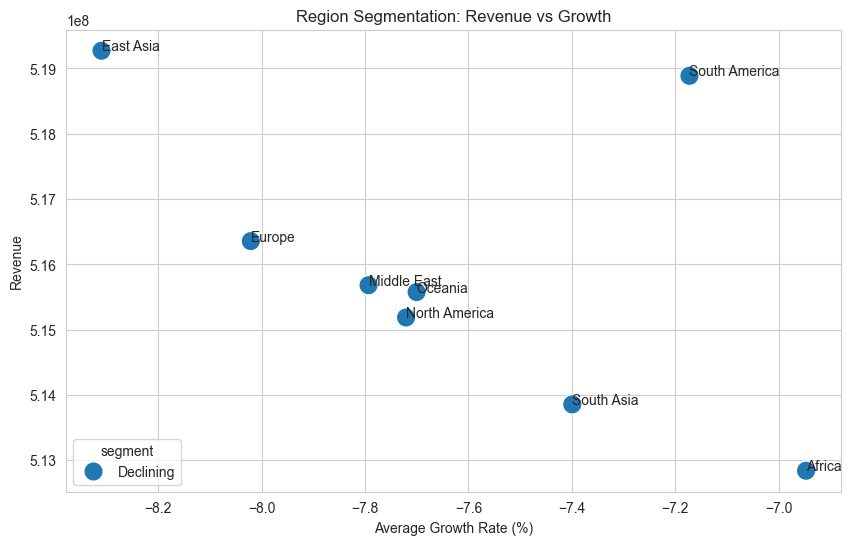

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=region_summary,
    x='avg_growth_rate',
    y='revenue',
    hue='segment',
    s=200
)

for i in range(len(region_summary)):
    plt.text(
        region_summary['avg_growth_rate'][i],
        region_summary['revenue'][i],
        region_summary['region'][i]
    )

plt.title('Region Segmentation: Revenue vs Growth')

plt.xlabel('Average Growth Rate (%)')
plt.ylabel('Revenue')

plt.show()

In [14]:
#Category Risk Segmentation

In [15]:
category_summary = (
    df.groupby('category')
    .agg({
        'revenue': 'sum',
        'units_sold': 'std'
    })
    .reset_index()
)

category_summary.columns = [
    'category',
    'revenue',
    'demand_volatility'
]

category_summary

,category,revenue,demand_volatility
0,Antibiotic,8.265009e+08,329.461767
1,Antipyretic,8.295979e+08,344.096363
2,Chronic,8.213407e+08,338.283020
3,Cough_Cold,8.276622e+08,337.068616
4,Vitamin,8.225529e+08,345.302626


In [16]:
#Risk Classification
median_volatility = (
    category_summary['demand_volatility']
    .median()
)

median_revenue = (
    category_summary['revenue']
    .median()
)

In [17]:
#Strategic Quadrants
def category_strategy(row):
    
    if (
        row['revenue'] >= median_revenue
        and row['demand_volatility'] >= median_volatility
    ):
        return 'High Revenue / High Risk'
    
    elif (
        row['revenue'] >= median_revenue
        and row['demand_volatility'] < median_volatility
    ):
        return 'High Revenue / Stable'
    
    elif (
        row['revenue'] < median_revenue
        and row['demand_volatility'] >= median_volatility
    ):
        return 'Low Revenue / High Risk'
    
    else:
        return 'Low Revenue / Stable'

category_summary['strategy_segment'] = (
    category_summary.apply(
        category_strategy,
        axis=1
    )
)

category_summary

,category,revenue,demand_volatility,strategy_segment
0,Antibiotic,8.265009e+08,329.461767,High Revenue / Stable
1,Antipyretic,8.295979e+08,344.096363,High Revenue / High Risk
2,Chronic,8.213407e+08,338.283020,Low Revenue / High Risk
3,Cough_Cold,8.276622e+08,337.068616,High Revenue / Stable
4,Vitamin,8.225529e+08,345.302626,Low Revenue / High Risk


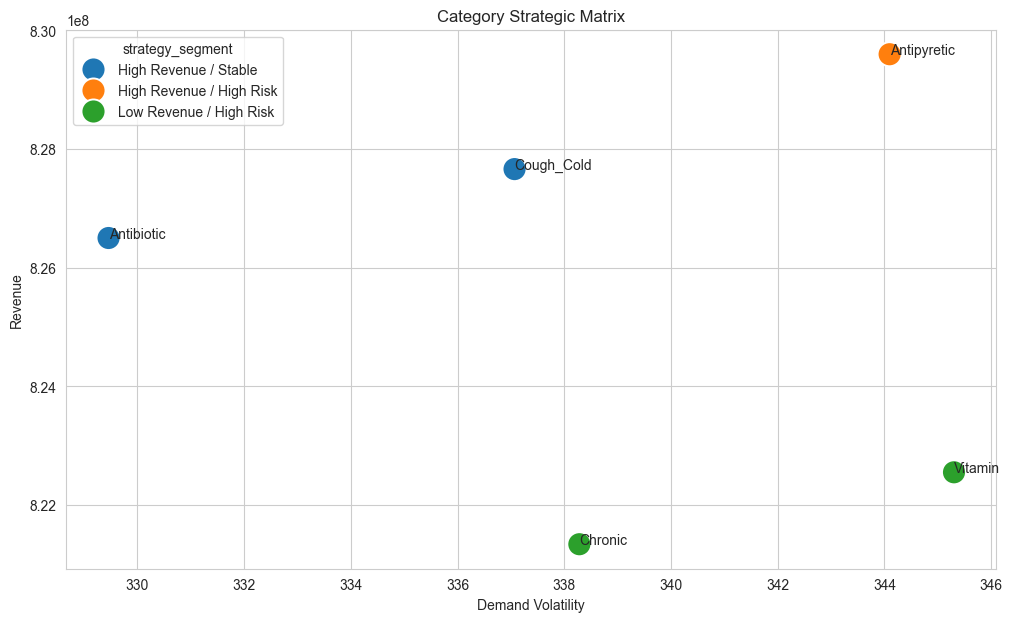

In [18]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=category_summary,
    x='demand_volatility',
    y='revenue',
    hue='strategy_segment',
    s=300
)

for i in range(len(category_summary)):
    plt.text(
        category_summary['demand_volatility'][i],
        category_summary['revenue'][i],
        category_summary['category'][i]
    )

plt.title('Category Strategic Matrix')

plt.xlabel('Demand Volatility')
plt.ylabel('Revenue')

plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [20]:
region_summary[['revenue_scaled',
                'growth_scaled',
                'stock_scaled']] = scaler.fit_transform(
    
    region_summary[['revenue',
                    'avg_growth_rate',
                    'stock_level']]
)

In [21]:
region_summary['performance_index'] = (
    
    region_summary['revenue_scaled'] * 0.5
    
    +
    
    region_summary['growth_scaled'] * 0.3
    
    +
    
    region_summary['stock_scaled'] * 0.2
)

In [22]:
region_summary = (
    region_summary.sort_values(
        by='performance_index',
        ascending=False
    )
)

region_summary

,region,revenue,units_sold,stock_level,avg_growth_rate,segment,revenue_scaled,growth_scaled,stock_scaled,performance_index
6,South America,5.188874e+08,9838549,4551.784945,-7.172679,Declining,0.940312,0.834489,0.000000,0.720503
1,East Asia,5.192713e+08,9837720,4551.934945,-8.309507,Declining,1.000000,0.000000,0.034353,0.506871
0,Africa,5.128403e+08,9733935,4556.151369,-6.947203,Declining,0.000000,1.000000,1.000000,0.500000
2,Europe,5.163563e+08,9782351,4554.947308,-8.020803,Declining,0.546727,0.211924,0.724246,0.481790
4,North America,5.151863e+08,9799919,4553.607162,-7.720614,Declining,0.364796,0.432277,0.417325,0.395546
5,Oceania,5.155757e+08,9847959,4552.617290,-7.700215,Declining,0.425342,0.447251,0.190624,0.384971
3,Middle East,5.156810e+08,9849229,4551.884717,-7.793134,Declining,0.441728,0.379044,0.022850,0.339147
7,South Asia,5.138564e+08,9844922,4552.133212,-7.399257,Declining,0.157992,0.668169,0.079760,0.295399


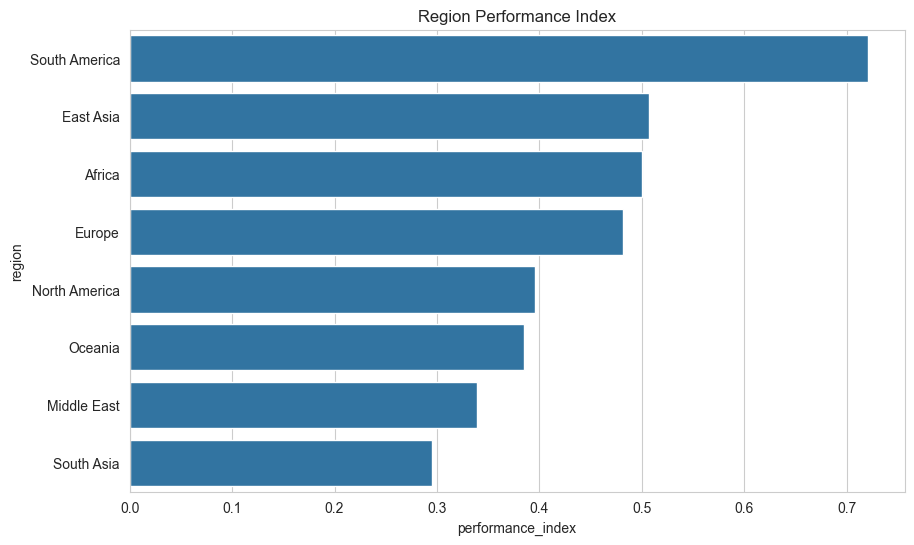

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=region_summary,
    x='performance_index',
    y='region'
)

plt.title('Region Performance Index')

plt.show()

In [24]:
regional_growth.to_csv(
    '../dashboard/regional_growth.csv',
    index=False
)

In [25]:
region_summary.to_csv(
    '../dashboard/region_summary.csv',
    index=False
)